# Encode Immune Human Dataset with scGPT

Encode the `Immune_ALL_human.h5ad` dataset using the pre-trained scGPT model
and stream embeddings to `data/immune_{model}_embeddings.h5ad`.

In [1]:
from pathlib import Path

import scanpy as sc
import torch

from scfm_utils.scgpt import (
    create_scgpt_dataset,
    encode_scgpt_embeddings_to_h5ad,
    load_cls_embeddings,
    load_average_gene_embeddings,
    load_scgpt_model,
)

/home/chasty2/Documents/scFM_benchmarking/.venv/lib/python3.12/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/home/chasty2/Documents/scFM_benchmarking/.venv/lib/python3.12/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/home/chasty2/Documents/scFM_benchmarking/.venv/lib/python3.12/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/home/chasty2/Documents/scFM_benchmarking/.venv/lib/python3.12/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHT

## Configuration

In [2]:
DATA_PATH = Path("../data/Immune_ALL_human.h5ad")
MODEL_DIR = Path("../models/scGPT_bc")
OUTPUT_PATH = Path("../data/immune_bc_embeddings.h5ad")
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Output: {OUTPUT_PATH}")

Device: cuda
Output: ../data/immune_bc_embeddings.h5ad


## Load model and data

In [3]:
bundle = load_scgpt_model(MODEL_DIR, device=DEVICE)
print(f"Model: {bundle.config['embsize']}d, {bundle.config['nlayers']} layers")
print(f"Vocab: {len(bundle.vocab)} genes")

Model: 512d, 12 layers
Vocab: 36574 genes


In [4]:
adata = sc.read(DATA_PATH, cache=True)
adata.obs["celltype"] = adata.obs["final_annotation"].astype(str)
print(f"Dataset: {adata.shape[0]} cells, {adata.shape[1]} genes")
print(f"Cell types: {adata.obs['celltype'].nunique()}")

Dataset: 33506 cells, 12303 genes
Cell types: 16


## Preprocess and create dataloader

In [5]:
scgpt_ds = create_scgpt_dataset(
    adata,
    vocab=bundle.vocab,
    gene2idx=bundle.gene2idx,
    batch_size=BATCH_SIZE,
)
print(f"Genes in vocab: {len(scgpt_ds.genes_in_vocab)}")
print(f"Batches: {len(scgpt_ds.dataloader)}")

scGPT - INFO - Filtering genes by counts ...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Subsetting highly variable genes ...
scGPT - INFO - Binning data ...
Genes in vocab: 1173
Batches: 524


## Encode and stream to h5ad

In [6]:
encode_scgpt_embeddings_to_h5ad(
    model=bundle.model,
    dataloader=scgpt_ds.dataloader,
    vocab=bundle.vocab,
    gene_names=scgpt_ds.genes_in_vocab,
    cell_types=adata.obs["celltype"].values,
    output_path=OUTPUT_PATH,
    device=DEVICE,
)
print(f"Embeddings saved to {OUTPUT_PATH}")

Encoding embeddings:   0%|          | 0/524 [00:00<?, ?it/s]/home/chasty2/Documents/scFM_benchmarking/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:408: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at ../aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)
Encoding embeddings: 100%|██████████| 524/524 [46:59<00:00,  5.38s/it]


Embeddings saved to ../data/immune_bc_embeddings.h5ad


## Sanity check: UMAP of CLS embeddings

Loaded CLS embeddings: (33506, 512)


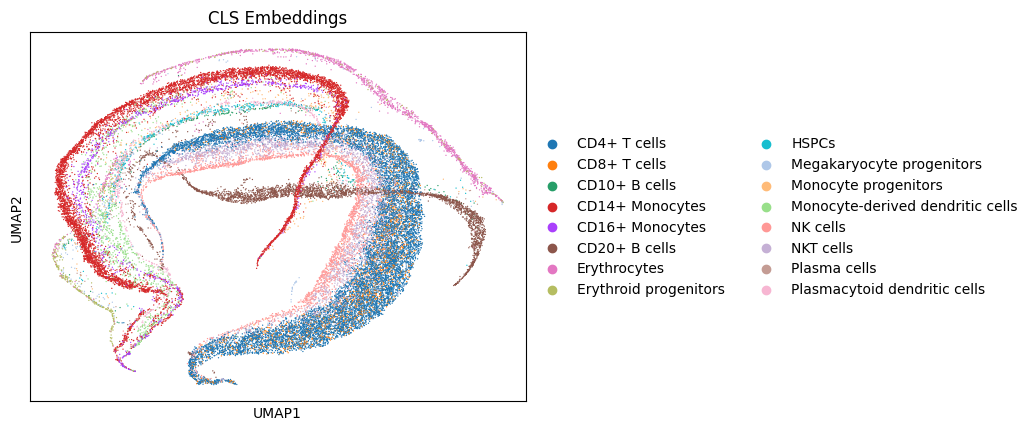

In [7]:
emb_adata = load_cls_embeddings(OUTPUT_PATH)
print(f"Loaded CLS embeddings: {emb_adata.shape}")

sc.pp.neighbors(emb_adata, use_rep="X")
sc.tl.umap(emb_adata)
sc.pl.umap(emb_adata, color="celltype", title="CLS Embeddings")

## Sanity check: averaged gene embeddings per cell type

In [8]:
import numpy as np

avgs, gene_names = load_average_gene_embeddings(OUTPUT_PATH)
print(f"Cell types: {len(avgs)}")
print(f"Number of Genes: {len(gene_names)}")
for cell_type, embeddings in avgs.items():
    print(f"  {cell_type}: {embeddings.shape}")

Cell types: 16
Number of Genes: 1173
  CD10+ B cells: (1173, 512)
  CD14+ Monocytes: (1173, 512)
  CD16+ Monocytes: (1173, 512)
  CD20+ B cells: (1173, 512)
  CD4+ T cells: (1173, 512)
  CD8+ T cells: (1173, 512)
  Erythrocytes: (1173, 512)
  Erythroid progenitors: (1173, 512)
  HSPCs: (1173, 512)
  Megakaryocyte progenitors: (1173, 512)
  Monocyte progenitors: (1173, 512)
  Monocyte-derived dendritic cells: (1173, 512)
  NK cells: (1173, 512)
  NKT cells: (1173, 512)
  Plasma cells: (1173, 512)
  Plasmacytoid dendritic cells: (1173, 512)
